<a href="https://colab.research.google.com/github/omran35/MSIS822-Project/blob/main/AI_Arabic_Text_Detection_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Class Distribution:
label
1    33549
0     8388
Name: count, dtype: int64

Dataset saved successfully!


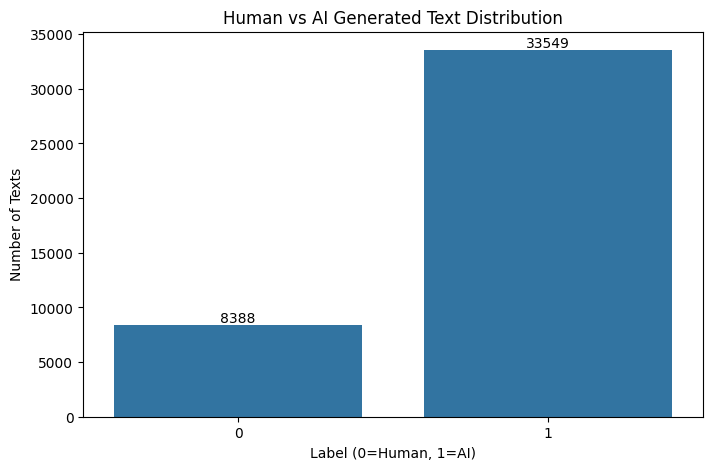

In [6]:
# ==========================================
# 6. Save Dataset & Visualization
# ==========================================


print("Class Distribution:")


distribution = (
    texts["label"]
    .value_counts()
)


print(distribution)



# Save CSV

texts.to_csv(
    "arabic_ai_detection_dataset.csv",
    index=False,
    encoding="utf-8"
)


print(
    "\nDataset saved successfully!"
)



# Visualization

plt.figure(
    figsize=(8,5)
)


ax = sns.countplot(
    data=texts,
    x="label"
)


plt.title(
    "Human vs AI Generated Text Distribution"
)


plt.xlabel(
    "Label (0=Human, 1=AI)"
)


plt.ylabel(
    "Number of Texts"
)


for container in ax.containers:
    ax.bar_label(container)



plt.show()

In [5]:
# ==========================================
# 5. Create Human vs AI Dataset
# ==========================================


texts = df_raw.melt(

    id_vars=[
        "generation_method"
    ],

    value_vars=[
        "original_abstract",
        "allam_generated_abstract",
        "jais_generated_abstract",
        "llama_generated_abstract",
        "openai_generated_abstract"
    ],

    var_name="text_source",

    value_name="text"

)



# Remove empty values

texts = texts.dropna()



# Create Labels

texts["label"] = (

    texts["text_source"]
    !=
    "original_abstract"

).astype(int)



# Remove duplicates

texts = texts.drop_duplicates()



print("Final Dataset Shape:")

print(
    texts.shape
)



display(
    texts.head()
)

Final Dataset Shape:
(41937, 4)


,generation_method,text_source,text,label
0,by_polishing,original_abstract,كثيرا ما ارتبطت المصادر التاريخية في الأندلس خ...,0
1,by_polishing,original_abstract,يعد العامل الثقافي احد ابرز الاسباب التي يعزى ...,0
2,by_polishing,original_abstract,شكلت تلك الجهود والمساعي الرائدة التي قام بها ...,0
3,by_polishing,original_abstract,يقوم المقال على اشكالية الضرائب الغير شرعية في...,0
4,by_polishing,original_abstract,تتفق المصادر التاريخية المتوفرة حول موضوع تطور...,0


In [4]:
# ==========================================
# 4. Data Quality Check
# ==========================================


print("========== Missing Values ==========")


missing = df_raw.isnull().sum()


display(
    missing
)



print("\n========== Duplicate Rows ==========")


duplicates = df_raw.duplicated().sum()


print(
    "Duplicate rows:",
    duplicates
)



print("\n========== Dataset Statistics ==========")


print(
    "Total Rows:",
    len(df_raw)
)

========== Missing Values ==========


,0
original_abstract,0
allam_generated_abstract,0
jais_generated_abstract,0
llama_generated_abstract,0
openai_generated_abstract,0
generation_method,0



========== Duplicate Rows ==========
Duplicate rows: 0

========== Dataset Statistics ==========
Total Rows: 8388


In [3]:
# ==========================================
# 3. Data Understanding
# ==========================================


frames = []


for name, subset in dataset.items():

    df = subset.to_pandas()

    df["generation_method"] = name

    frames.append(df)



# Combine all subsets

df_raw = pd.concat(
    frames,
    ignore_index=True
)


print("Dataset Shape:")
print(df_raw.shape)



print("\nColumns:")

print(
    df_raw.columns
)



print("\nFirst Samples:")

display(
    df_raw.head()
)



print("\nData Information:")

df_raw.info()

Dataset Shape:
(8388, 6)

Columns:
Index(['original_abstract', 'allam_generated_abstract',
       'jais_generated_abstract', 'llama_generated_abstract',
       'openai_generated_abstract', 'generation_method'],
      dtype='object')

First Samples:


,original_abstract,allam_generated_abstract,jais_generated_abstract,llama_generated_abstract,openai_generated_abstract,generation_method
0,كثيرا ما ارتبطت المصادر التاريخية في الأندلس خ...,يتناول هذا البحث موضوع التعليم بين النساء الأن...,تدرس هذه الدراسة دور المرأة في التعليم في الأن...,يُقدم هذا البحث دراسة شاملة حول حالة التعليم ع...,صور نظام التعليم عند المرأة الأندلسية تستند إل...,by_polishing
1,يعد العامل الثقافي احد ابرز الاسباب التي يعزى ...,يتناول هذا البحث دراسة انهيار دولة الموحدين من...,كان العامل الثقافي من بين الأسباب الرئيسية الت...,يعد العامل الثقافي أحد أبرز الأسباب التي يعزى ...,انهيار دولة الموحدين يعود بشكل كبير للعوامل ال...,by_polishing
2,شكلت تلك الجهود والمساعي الرائدة التي قام بها ...,هدفت هذه الدراسة إلى تسليط الضوء على جهود قادة...,تدرس هذه الدراسة جهود قادة الثورة الجزائرية خل...,شكلت الجهود التي بذلها قادة الثورة الجزائرية خ...,جهود قادة الثورة الجزائرية خلال المرحلة الأولى...,by_polishing
3,يقوم المقال على اشكالية الضرائب الغير شرعية في...,يتناول هذا البحث إشكالية الضرائب غير الشرعية ف...,تدرس المقالة مشكلة الضرائب غير الشرعية في مراح...,يقوم البحث على دراسة الضرائب غير الشرعية في دو...,المقال يناقش قضية الضرائب غير الشرعية في دولتي...,by_polishing
4,تتفق المصادر التاريخية المتوفرة حول موضوع تطور...,تتناول هذه الدراسة حركة الانتصار للحريات الديم...,حركة انتصار الحريات الديمقراطية (MTLD)، وهي حر...,تُظهر المصادر التاريخية المتاحة حول تطور الحرك...,حركة انتصار الحريات الديمقراطية (MTLD) في الجز...,by_polishing



Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8388 entries, 0 to 8387
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   original_abstract          8388 non-null   object
 1   allam_generated_abstract   8388 non-null   object
 2   jais_generated_abstract    8388 non-null   object
 3   llama_generated_abstract   8388 non-null   object
 4   openai_generated_abstract  8388 non-null   object
 5   generation_method          8388 non-null   object
dtypes: object(6)
memory usage: 393.3+ KB


In [2]:
# ==========================================
# 2. Load Dataset from Hugging Face
# ==========================================


dataset = load_dataset(
    "KFUPM-JRCAI/arabic-generated-abstracts"
)


print(dataset)

DatasetDict({
    by_polishing: Dataset({
        features: ['original_abstract', 'allam_generated_abstract', 'jais_generated_abstract', 'llama_generated_abstract', 'openai_generated_abstract'],
        num_rows: 2851
    })
    from_title: Dataset({
        features: ['original_abstract', 'allam_generated_abstract', 'jais_generated_abstract', 'llama_generated_abstract', 'openai_generated_abstract'],
        num_rows: 2963
    })
    from_title_and_content: Dataset({
        features: ['original_abstract', 'allam_generated_abstract', 'jais_generated_abstract', 'llama_generated_abstract', 'openai_generated_abstract'],
        num_rows: 2574
    })
})


In [1]:
# ==========================================
# 1. Install & Import Libraries
# ==========================================

!pip install datasets==3.1.0 pandas matplotlib seaborn


from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


print("Libraries loaded successfully!")

Libraries loaded successfully!
